# Detecção de Fraudes em Transações de Cartão de Crédito

Este projeto tem como objetivo a construção de um modelo de classificação para identificar transações fraudulentas. Devido ao extremo desbalanceamento das classes no mundo real, a abordagem foge da simples otimização de algoritmos e foca em técnicas de validação robustas (Out-of-Time Validation), tratamento de classes e otimização do limiar de decisão (threshold) com base em custos de negócio.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score

from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

pd.set_option("display.max_columns", 40)


## 1. Carregamento e Exploração dos Dados
Os dados contêm variáveis numéricas resultantes de uma transformação PCA (V1 a V28), além do tempo cronológico (`Time`) e do valor da transação (`Amount`). A variável alvo é a `Class` (1 para fraude, 0 para transação legítima).


In [2]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df["Class"].value_counts(normalize=True)


Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

O dataset é altamente desbalanceado (fraudes representam menos de 0,2% do volume). Modelos treinados sem o devido tratamento tendem a gerar uma quantidade crítica de falsos negativos. O foco de avaliação deste projeto será nas métricas de Precisão, Recall e, principalmente, no impacto financeiro das predições.


## 2. Preparação dos Dados
Aplicação de transformação logarítmica na variável `Amount` para atenuar a assimetria da distribuição e reduzir o impacto de outliers no treinamento.


In [4]:
df["Amount_log"] = np.log1p(df["Amount"])


### 2.1 Separação Temporal (Out-of-Time Validation)
Para simular um ambiente de produção realista e evitar *data leakage* (vazamento de dados do futuro para o treino), a separação entre treino e validação é feita com base na ordem cronológica das transações, substituindo o tradicional split aleatório.
Aproveitando a ordenação cronológica do conjunto de dados, foram derivadas variáveis de contexto a partir da coluna `Time`, como a hora do dia e o volume sistêmico de transações na última hora. Na ausência de um ID de cliente/cartão, a frequência agregada atua como um *proxy* comportamental importante, visto que as fraudes tendem a apresentar padrões de concentração fora dos horários de pico das transações legítimas.


In [ ]:
df_sorted = df.sort_values("Time").reset_index(drop=True)

# Derivação de features temporais usando janelas retroativas (rolling)
# O cálculo é estritamente sobre o passado, prevenindo data leakage
df_sorted["hour_of_day"] = (df_sorted["Time"] % 86400) // 3600
df_sorted["seconds_since_prev"] = df_sorted["Time"].diff().fillna(0)

time_idx = pd.to_timedelta(df_sorted["Time"], unit="s")
df_sorted["txns_last_hour"] = (
    df_sorted.set_index(time_idx)["Amount"].rolling("3600s").count().values
)

split_idx = int(len(df_sorted) * 0.7)
train_df = df_sorted.iloc[:split_idx].copy()
test_df = df_sorted.iloc[split_idx:].copy()

print(f"Treino: {len(train_df)} linhas, {train_df['Class'].sum()} fraudes ({train_df['Class'].mean()*100:.3f}%)")
print(f"Teste:  {len(test_df)} linhas, {test_df['Class'].sum()} fraudes ({test_df['Class'].mean()*100:.3f}%)")


Treino: 199364 linhas, 384 fraudes (0.193%)
Teste:  85443 linhas, 108 fraudes (0.126%)


### 2.2 Padronização
O `StandardScaler` é ajustado (`fit`) exclusivamente nos dados de treino para garantir a integridade estatística do conjunto de validação.

In [6]:
scaler = StandardScaler()
train_df["Amount_scaled"] = scaler.fit_transform(train_df[["Amount_log"]])
test_df["Amount_scaled"] = scaler.transform(test_df[["Amount_log"]])

feature_cols = [c for c in train_df.columns if c not in ["Time", "Amount", "Amount_log", "Class"]]
X_train, y_train = train_df[feature_cols], train_df["Class"]
X_test, y_test = test_df[feature_cols], test_df["Class"]


## 3. Modelagem
### 3.1 Modelo Baseline (Random Forest)
Treinamento de um modelo inicial utilizando o parâmetro `class_weight='balanced'` para lidar com o desbalanceamento alterando a função de custo do algoritmo, sem gerar dados artificiais.

In [7]:
rf_balanced = RandomForestClassifier(
    n_estimators=50, max_depth=10, class_weight="balanced", random_state=42
)
rf_balanced.fit(X_train, y_train)
proba_balanced = rf_balanced.predict_proba(X_test)[:, 1]
pred_balanced = (proba_balanced >= 0.5).astype(int)

print(classification_report(y_test, pred_balanced, digits=3))
print("ROC AUC:", round(roc_auc_score(y_test, proba_balanced), 4))


              precision    recall  f1-score   support

           0      1.000     1.000     1.000     85335
           1      0.883     0.769     0.822       108

    accuracy                          1.000     85443
   macro avg      0.941     0.884     0.911     85443
weighted avg      1.000     1.000     1.000     85443

ROC AUC: 0.9747


### 3.2 Avaliação de Oversampling (SMOTE)
Comparação da abordagem de penalização (`class_weight`) com a geração de dados sintéticos via SMOTE. A aplicação do SMOTE é rigorosamente restrita ao conjunto de treino para garantir que as métricas sejam avaliadas em dados 100% reais.

In [8]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f"Treino original: {len(X_train)} linhas | Treino com SMOTE: {len(X_train_sm)} linhas")

rf_smote = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf_smote.fit(X_train_sm, y_train_sm)
pred_smote = rf_smote.predict(X_test)
proba_smote = rf_smote.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_smote, digits=3))
print("ROC AUC:", round(roc_auc_score(y_test, proba_smote), 4))


Treino original: 199364 linhas | Treino com SMOTE: 397960 linhas
              precision    recall  f1-score   support

           0      1.000     0.999     0.999     85335
           1      0.458     0.806     0.584       108

    accuracy                          0.999     85443
   macro avg      0.729     0.902     0.792     85443
weighted avg      0.999     0.999     0.999     85443

ROC AUC: 0.9767


## 4. Otimização do Limiar de Decisão (Foco em Negócio)
O ponto de corte probabilístico padrão (0.5) raramente reflete a realidade operacional de uma área de risco. Para este projeto, o *threshold* ideal é calculado com o objetivo de minimizar o prejuízo financeiro esperado:

*   **Falso Negativo:** Custo variável. A fraude que passa despercebida custa o valor real daquela transação específica.
*   **Falso Positivo:** Custo fixo estimado. Bloquear uma transação legítima gera custo operacional (atendimento, revisão) e atrito com o cliente.

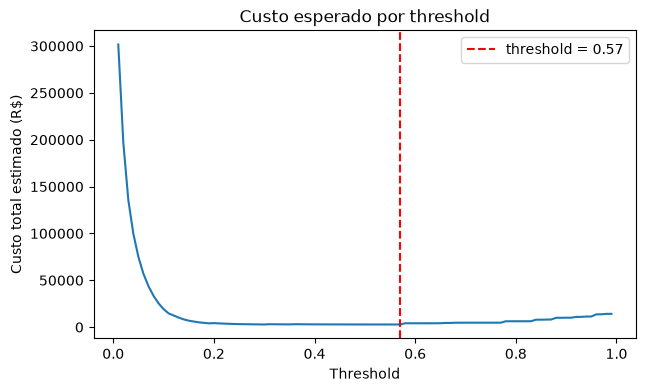

Threshold escolhido: 0.57 | custo mínimo estimado: R$ 2806.72


In [9]:
cost_fp = 5.0  # custo estimado de investigar um alarme falso

def escolher_threshold_por_custo(proba_arr, y_true_arr, amount_arr, cost_fp, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)
    custos = []
    for t in thresholds:
        preds_t = (proba_arr >= t).astype(int)
        fn_mask = (preds_t == 0) & (y_true_arr == 1)
        fp_count = ((preds_t == 1) & (y_true_arr == 0)).sum()
        custo_fn = amount_arr[fn_mask].sum()  # soma o valor real das fraudes que passaram batidas
        custos.append(custo_fn + fp_count * cost_fp)
    custos = np.array(custos)
    return thresholds[int(np.argmin(custos))], custos, thresholds

y_test_arr = y_test.values
amount_test_arr = test_df["Amount"].values

best_threshold, custos, thresholds = escolher_threshold_por_custo(
    proba_balanced, y_test_arr, amount_test_arr, cost_fp
)

plt.figure(figsize=(7, 4))
plt.plot(thresholds, custos)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Custo total estimado (R$)")
plt.title("Custo esperado por threshold")
plt.legend()
plt.show()

print(f"Threshold escolhido: {best_threshold:.2f} | custo mínimo estimado: R$ {custos.min():.2f}")


In [10]:
pred_custo = (proba_balanced >= best_threshold).astype(int)
print(classification_report(y_test, pred_custo, digits=3))


              precision    recall  f1-score   support

           0      1.000     1.000     1.000     85335
           1      0.932     0.759     0.837       108

    accuracy                          1.000     85443
   macro avg      0.966     0.880     0.918     85443
weighted avg      1.000     1.000     1.000     85443



## 5. Feature Engineering: Modelagem de Anomalias
Modelos supervisionados limitam-se a identificar padrões históricos já mapeados. Para adicionar capacidade de detecção de fraudes inéditas (*zero-day*), um algoritmo não-supervisionado (`IsolationForest`) é utilizado para calcular um *anomaly score*. Esse score é então incorporado como uma nova feature para o modelo preditivo final.

In [11]:
iso_forest = IsolationForest(
    n_estimators=200, contamination=float(y_train.mean()), random_state=42
)
iso_forest.fit(X_train)

X_train_ext = X_train.copy()
X_test_ext = X_test.copy()
X_train_ext["anomaly_score"] = -iso_forest.score_samples(X_train)
X_test_ext["anomaly_score"] = -iso_forest.score_samples(X_test)

X_train_ext[["anomaly_score"]].describe()


,anomaly_score
count,199364.000000
mean,0.410687
std,0.042285
min,0.348667
25%,0.382083
50%,0.400971
75%,0.427488
max,0.735341


## 6. Treinamento do Modelo Final (XGBoost)
Treinamento do modelo Gradient Boosting utilizando o dataset estendido (com a nova feature de anomalia) e a aplicação da otimização de threshold baseada na matriz de custos de negócio.

In [12]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    eval_metric="logloss", random_state=42
)
xgb_model.fit(X_train_ext, y_train)
proba_final = xgb_model.predict_proba(X_test_ext)[:, 1]

threshold_final, custos_final, _ = escolher_threshold_por_custo(
    proba_final, y_test_arr, amount_test_arr, cost_fp
)
pred_final = (proba_final >= threshold_final).astype(int)

print(f"Threshold: {threshold_final:.2f}")
print(classification_report(y_test, pred_final, digits=3))
print("ROC AUC:", round(roc_auc_score(y_test, proba_final), 4))


Threshold: 0.03
              precision    recall  f1-score   support

           0      1.000     0.998     0.999     85335
           1      0.366     0.806     0.503       108

    accuracy                          0.998     85443
   macro avg      0.683     0.902     0.751     85443
weighted avg      0.999     0.998     0.998     85443

ROC AUC: 0.9652


## 7. Interpretabilidade do Modelo (SHAP)
Uso dos valores SHAP (SHapley Additive exPlanations) para analisar o impacto individual e global das variáveis, garantindo transparência técnica e justificativa de negócio para as predições.

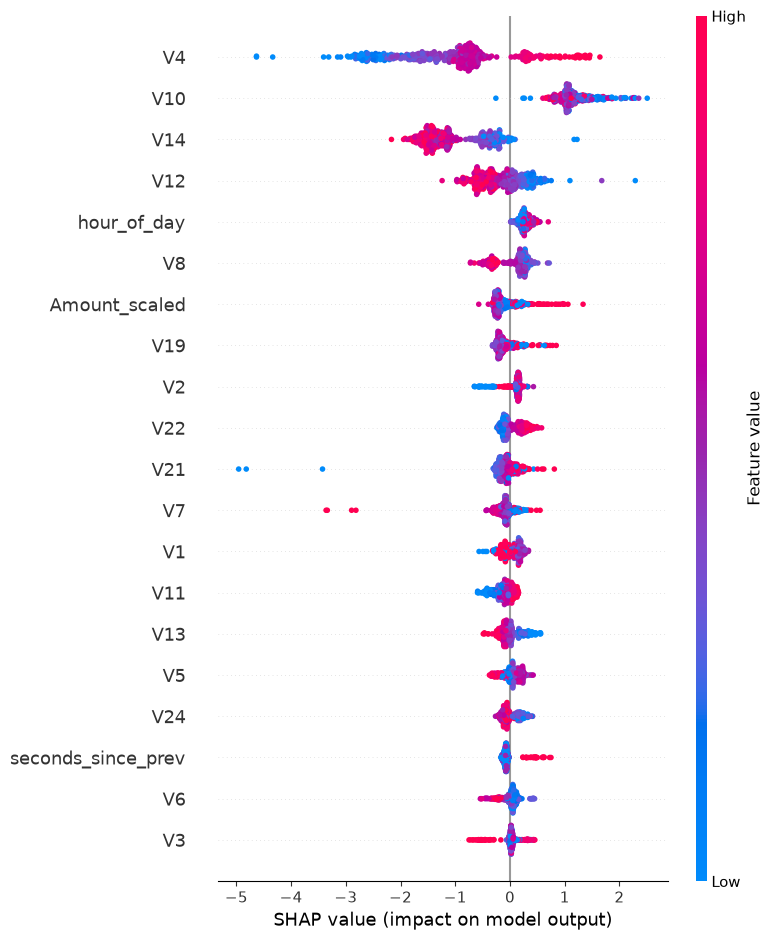

In [13]:
explainer = shap.TreeExplainer(xgb_model)

sample_idx = X_test_ext.sample(min(500, len(X_test_ext)), random_state=42).index
shap_values_sample = explainer.shap_values(X_test_ext.loc[sample_idx])

shap.summary_plot(shap_values_sample, X_test_ext.loc[sample_idx], show=True)


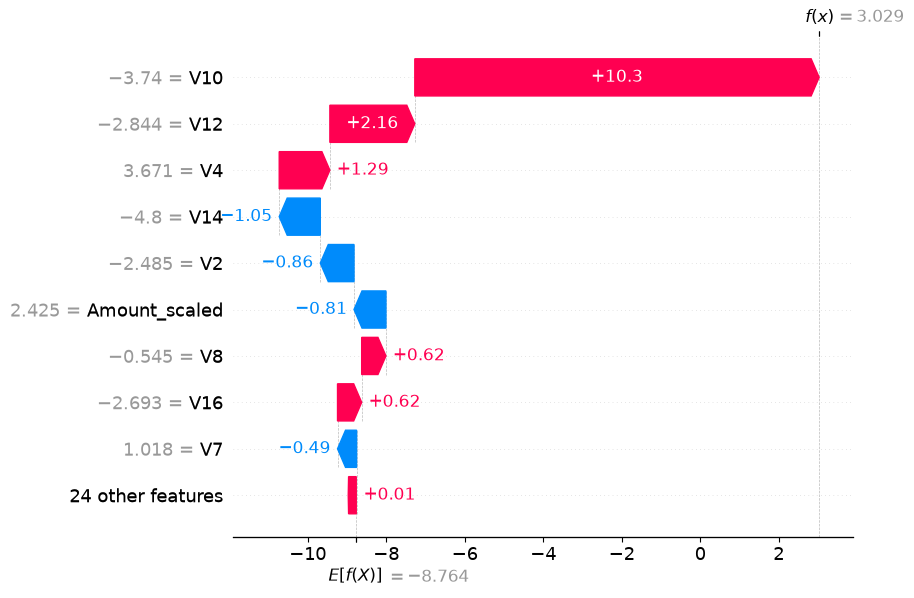

In [14]:
fraud_idx_test = y_test[y_test == 1].index
if len(fraud_idx_test) > 0:
    exemplo = X_test_ext.loc[[fraud_idx_test[0]]]
    exp_individual = explainer(exemplo)
    shap.plots.waterfall(exp_individual[0], show=True)
else:
    print("Nenhuma fraude no conjunto de teste para exemplificar.")


## Comparando as abordagens


In [15]:
def linha_metricas(nome, y_true, y_pred):
    return {
        "Modelo": nome,
        "Precision (fraude)": round(precision_score(y_true, y_pred, zero_division=0), 3),
        "Recall (fraude)": round(recall_score(y_true, y_pred, zero_division=0), 3),
        "F1 (fraude)": round(f1_score(y_true, y_pred, zero_division=0), 3),
    }

resultados = pd.DataFrame([
    linha_metricas("Random Forest (class_weight, threshold 0.5)", y_test, pred_balanced),
    linha_metricas("Random Forest + SMOTE (threshold 0.5)", y_test, pred_smote),
    linha_metricas(f"Random Forest (threshold por custo = {best_threshold:.2f})", y_test, pred_custo),
    linha_metricas(f"XGBoost final (threshold por custo = {threshold_final:.2f})", y_test, pred_final),
])
resultados


,Modelo,Precision (fraude),Recall (fraude),F1 (fraude)
0,"Random Forest (class_weight, threshold 0.5)",0.883,0.769,0.822
1,Random Forest + SMOTE (threshold 0.5),0.458,0.806,0.584
2,Random Forest (threshold por custo = 0.57),0.932,0.759,0.837
3,XGBoost final (threshold por custo = 0.03),0.366,0.806,0.503


## 8. Avaliação Operacional (Precision@k e Recall@k)

Métricas baseadas em um limiar (threshold) fixo são vitais para a decisão automatizada, mas não refletem o gargalo operacional de um time de prevenção a fraudes, que possui uma capacidade limitada de investigações manuais diárias. 

A abordagem via **Precision@k** e **Recall@k** resolve isso medindo o desempenho do modelo estritamente sobre as *k* transações ranqueadas com maior probabilidade de fraude. Isso responde à principal pergunta de negócio: "Dos 100 alertas que o time consegue analisar hoje, qual a taxa de acerto do modelo?"

In [16]:
def precision_recall_em_k(y_true_arr, proba_arr, k):
    top_k = np.argsort(proba_arr)[::-1][:k]
    acertos = y_true_arr[top_k].sum()
    total_fraudes = y_true_arr.sum()
    precisao_k = acertos / k
    cobertura_k = acertos / total_fraudes if total_fraudes > 0 else np.nan
    return precisao_k, cobertura_k

linhas_k = []
for k in [20, 50, 100, 200]:
    p_k, r_k = precision_recall_em_k(y_test_arr, proba_final, k)
    linhas_k.append({"Top k alertas": k, "Precision@k": round(p_k, 3), "Recall@k": round(r_k, 3)})

pd.DataFrame(linhas_k)


,Top k alertas,Precision@k,Recall@k
0,20,0.900,0.167
1,50,0.960,0.444
2,100,0.750,0.694
3,200,0.425,0.787


## Conclusões do Projeto

A construção deste pipeline demonstrou que, em cenários de fraude, o rigor na validação e a visão de negócio são mais impactantes que a complexidade do algoritmo em si. As principais entregas operacionais incluem:
*   **Out-of-Time Validation:** Garantia de que as métricas do modelo refletem um cenário real de produção (previsão do futuro baseado no passado).
*   **Threshold Baseado em Custos:** Substituição da otimização cega de métricas estatísticas (como F1-Score) por uma abordagem que minimiza ativamente o prejuízo financeiro da instituição.
*   **Combinação de Sinais:** A utilização de scores de anomalia não-supervisionados como *features* agregou poder preditivo ao modelo principal de forma controlada.*   **Precision@k:** Leitura dos resultados pela ótica operacional de um time de investigação, que analisa um volume fixo de alertas por dia em vez do dataset inteiro.
